In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ecommerce_data.csv')
df.head()

,order_id,product_name,category,discount_percentage,rating,rating_count,price,quantity_sold
0,ORD001,Phone A,Electronics,10,4.2,120,15000,30
1,ORD002,Phone B,Electronics,25,4.5,340,18000,55
2,ORD003,Laptop A,Electronics,15,4.0,210,55000,20
3,ORD004,Shoes A,Fashion,40,4.3,500,3000,80
4,ORD005,Shirt A,Fashion,35,3.8,150,1200,60


In [3]:
df.describe()

,discount_percentage,rating,rating_count,price,quantity_sold
count,15.000000,15.00000,15.000000,15.000000,15.000000
mean,30.333333,4.18000,376.000000,13113.333333,58.333333
std,16.417180,0.37645,300.447286,19068.106006,29.620617
min,10.000000,3.50000,80.000000,1200.000000,15.000000
25%,17.500000,3.95000,165.000000,2500.000000,35.000000
50%,25.000000,4.20000,220.000000,3500.000000,60.000000
75%,42.500000,4.45000,550.000000,16500.000000,77.500000
max,60.000000,4.80000,950.000000,60000.000000,110.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             15 non-null     object 
 1   product_name         15 non-null     object 
 2   category             15 non-null     object 
 3   discount_percentage  15 non-null     int64  
 4   rating               15 non-null     float64
 5   rating_count         15 non-null     int64  
 6   price                15 non-null     int64  
 7   quantity_sold        15 non-null     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 1.1+ KB


In [5]:
df.isnull().sum()

order_id               0
product_name           0
category               0
discount_percentage    0
rating                 0
rating_count           0
price                  0
quantity_sold          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(15, 8)

In [13]:
df.drop(columns = 'order_id', inplace = True)

In [14]:
df.head()

,category,discount_percentage,rating,rating_count,price,quantity_sold
0,Electronics,10,4.2,120,15000,30
1,Electronics,25,4.5,340,18000,55
2,Electronics,15,4.0,210,55000,20
3,Fashion,40,4.3,500,3000,80
4,Fashion,35,3.8,150,1200,60


In [20]:
df[['discount_percentage','rating','quantity_sold']].corr()

,discount_percentage,rating,quantity_sold
discount_percentage,1.000000,0.729283,0.955981
rating,0.729283,1.000000,0.755880
quantity_sold,0.955981,0.755880,1.000000


In [21]:
high_discount = df[df['discount_percentage']>30]['quantity_sold']
low_discount = df[df['discount_percentage'] <= 30]['quantity_sold']

In [22]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_discount, low_discount)

print("P-value:", p_value)

P-value: 0.0005319187385420337


Interpretation:
p < 0.05 → significant impact
p > 0.05 → no strong evidence

In [25]:
from sklearn.linear_model import LinearRegression
X = df[['discount_percentage', 'rating']]
Y = df['quantity_sold']
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
print("Coefficients:", model.coef_)

Coefficients: [1.5598366  9.86608395]


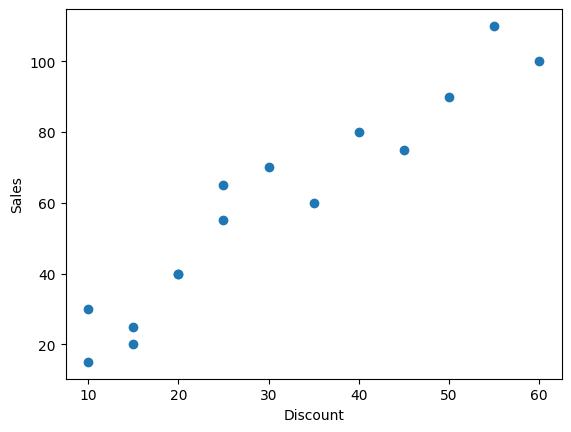

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df['discount_percentage'], df['quantity_sold'])
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
X = df[['discount_percentage', 'rating']]
Y = df['quantity_sold']
model = RandomForestRegressor()
model.fit(X,Y)
print("feature importance:", model.feature_importances_)


KeyError: "['discounted_percentage'] not in index"